# Inverse design optimization of a compact grating coupler

**This notebook contains a long optimization. Running the entire
notebook will cost about 10 FlexCredits and take a few hours.**

The ability to couple light in and out of photonic integrated circuits
(PICs) is crucial for developing wafer-scale systems and tests. This
need makes designing efficient and compact grating couplers an important
task in the PIC development cycle. In this notebook, we will demonstrate
how to use `tidy3d` to perform the inverse design of a compact 3D
grating coupler. We will show how to improve design fabricability by
enhancing permittivity binarization and controlling the device’s minimum
feature size, as well as applying a strict topological connectivity constraint.

If you are new to the finite-difference time-domain (FDTD) method, we
highly recommend going through our
[FDTD101](https://www.flexcompute.com/fdtd101/) tutorials. FDTD
simulations can diverge due to various reasons. If you run into any
simulation divergence issues, please follow the steps outlined in our
[troubleshooting
guide](https://www.flexcompute.com/tidy3d/examples/notebooks/DivergedFDTDSimulation/)
to resolve it.

We start by importing our typical python packages, plus `autograd` and
`tidy3d`.

In [1]:
# Standard python imports.
from typing import List

# Import autograd to be able to use automatic differentiation.
import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np
import scipy as sp

# Import regular tidy3d.
import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad

## Grating Coupler Inverse Design Configuration

The grating coupler inverse design begins with a rectangular design
region connected to a waveguide. Throughout the optimization
process, this initial structure evolves to convert a vertically incident
Gaussian-like mode from an optical fiber into a guided mode and then
funnel it into the waveguide on the right.

The structure consists exclusively of Tantala (n=2.036) suspended in vacuum (no substrate).

In the following block of code, you can find the parameters that can be
modified to configure the grating coupler structure, optimization, and
simulation setup.

In [2]:
# Geometric parameters.
thickness = 0.8  # Waveguide thickness (um).
wg_width = 1.7  # Waveguide width (um).
wg_length = 1.0  # Waveguide length (um).
beam_tilt_angle = 0.0  # tilt angle (degrees).
beam_focus_offset = 0.05  # Distance between the source focus and device (um).

# Material.
n_tantala = 2.036  # Tantala refractive index.

# Design region parameters.
gc_width = 7.0  # Grating coupler width (um).
gc_length = 7.0  # Grating coupler length (um).
dr_grid_size = 0.02  # Grid size within the design region (um).

# Inverse design setup parameters.
#################################################################
# Total number of iterations = num_optimize_step x iter_per_step.
# iter_per_step = 1  # Number of iterations per optimization step.
# num_optimize_step = 20  # Number of optimization steps.
#################################################################
proj_filter_threshold = 0.50  # Threshold value for the projection filter.
eta = proj_filter_threshold  # Threshold value for the projection filter.
FoM_name = "FoM_field"  # Name of the monitor used to compute the objective function.

# Simulation wavelength.
wavelength = 2.923  # Central simulation wavelength (um).
wavelength_width = 0.1  # Simulation bandwidth (um).
num_wavelength_points = 61  # Number of wavelength points within the bandwidth.

# feature size
min_feature_size = 0.08
filter_radius = min_feature_size

# Buffer layer thickness
border_buffer = 0.16



In [3]:
# total_iter = num_optimize_step * iter_per_step
# print(f"Total iterations = {total_iter}")

## Inverse Design Optimization Set Up

We will calculate the values of some parameters used throughout the
inverse design set up.

In [4]:
# Minimum and maximum values for the permittivities.
eps_max = n_tantala**2
eps_min = 1.0

# Material definitions.
mat_tantala = td.Medium(permittivity=eps_max)  # Tantala material.

# Wavelengths and frequencies.
max_wavelength = wavelength + wavelength_width / 2
min_wavelength = wavelength - wavelength_width / 2
wavelength_array = np.linspace(min_wavelength, max_wavelength, num_wavelength_points)
freq = td.C_0 / wavelength
freq_array = td.C_0 / wavelength_array
freq_width = 0.5 * (freq_array[0] - freq_array[-1])
run_time = 1000e-15

# Inverse design variables.
dr_num_grid_x = int((gc_length + 2 * border_buffer) / dr_grid_size)
dr_num_grid_y = int((gc_width + 2 * border_buffer) / dr_grid_size / 2.0)
dr_num_grid_border = int(border_buffer / dr_grid_size)
dr_num_grid_tot = int(dr_num_grid_x * dr_num_grid_y)
dr_size_x = dr_num_grid_x * dr_grid_size
dr_size_y = 2 * dr_num_grid_y * dr_grid_size

# Position coordinates - Coupler on the left, waveguide on the right
dr_center_x = 0.0
wg_start_x = dr_size_x / 2.0

# Computational domain size.
pml_spacing = 0.6 * wavelength
sim_size_x = dr_size_x + wg_length + 2 * pml_spacing
sim_size_y = dr_size_y + 2 * pml_spacing
sim_size_z = thickness + 2 * pml_spacing

sim_center_x = wg_length / 2.0  # Center simulation over the total length
sim_center_y = 0.0
sim_center_z = 0.0
sim_min_steps_per_wvl = 15
effective_inf = 1000

beam_pos_z = thickness / 2 + beam_focus_offset
mon_pos_x = wg_start_x + wg_length * 0.75
mon_width = int(3 * wg_width / dr_grid_size) * dr_grid_size
mon_height = int(5 * thickness / dr_grid_size) * dr_grid_size

First, we will introduce the simulation components that do not change
during optimization, such as the Tantala waveguide. Since there is no substrate, only the waveguide
is manually added. 

Additionally, we will include a Gaussian source with the specified waist radius to drive the
simulations, and a mode monitor to compute the objective function.

In [5]:
# Output waveguide.
waveguide = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(wg_start_x, -wg_width/2, -thickness/2),
        rmax=(effective_inf, wg_width/2, thickness/2),
    ),
    medium=mat_tantala,
)

# Gaussian source focused above the grating coupler.
gaussian_beam = td.GaussianBeam(
    center=(dr_center_x, 0, beam_pos_z),
    size=(dr_size_x - 2 * border_buffer, dr_size_y - 2 * border_buffer, 0),
    source_time=td.GaussianPulse(freq0=freq, fwidth=freq_width),
    pol_angle=np.pi/2,
    angle_theta=beam_tilt_angle * np.pi / 180.0,
    direction="-",
    num_freqs=7,
    waist_radius=2.6210,  # Defined waist of the beam
)

# Monitor where we will compute the objective function from.
FoM_monitor = td.ModeMonitor(
    center=[mon_pos_x, 0, 0],
    size=[0, mon_width, mon_height],
    freqs=[freq],
    mode_spec=td.ModeSpec(num_modes=1, target_neff=n_tantala),
    name=FoM_name,
)

Now, we will define a random vector of initial design parameters or load
a previously designed structure.

In [6]:
init_par = np.random.uniform(0, 1, int(dr_num_grid_tot))
init_par = sp.ndimage.gaussian_filter(init_par.reshape((dr_num_grid_x, dr_num_grid_y)), 1)

### Fabrication Constraints

We will use the `tidy3d.plugins.autograd` plugin to introduce functions
that improve device fabricability. A classical conic density filter,
which is popular in topology optimization problems, is used to enforce a
minimum feature size specified by the `filter_radius` variable. 

The border buffer operates effectively as a solid rectangle frame. We use `interface_buffer` to strictly enforce the boundary to 1s (representing solid Tantala). The optimizer is technically passed the entire grid, but the edge updates are strictly overridden.

In [7]:
from tidy3d.plugins.autograd import make_filter_and_project, rescale

filter_project = make_filter_and_project(filter_radius, dr_grid_size, padding="constant")

def interface_buffer(params):
    """Introduce a solid frame around the design to enhance fabricability and connectivity."""
    # Create Numpy arrays internally so autograd avoids "item assignment" errors.
    mask_np = np.zeros(params.shape)
    mask_np[0:dr_num_grid_border, :] = 1.0
    mask_np[dr_num_grid_x - dr_num_grid_border :, :] = 1.0
    mask_np[:, dr_num_grid_y - dr_num_grid_border :] = 1.0
    
    mask = anp.array(mask_np)
    return params * (1.0 - mask) + mask

def pre_process(params, beta):
    """Get the permittivity values (1, eps_wg) array as a function of the parameters (0,1)"""
    params1 = interface_buffer(params)
    params2 = filter_project(params1, beta=beta)
    params3 = filter_project(params2, beta=beta)
    return params3

def get_eps_values(params: np.ndarray, beta: float) -> np.ndarray:
    """Get the relative permittivity array given the parameters."""
    params = pre_process(params, beta=beta)
    eps_values = rescale(params, eps_min, eps_max)
    return eps_values

def get_eps(design_param: np.ndarray, beta: float = 1.00, binarize: bool = False) -> np.ndarray:
    """Returns the permittivities for the simulation."""
    eps = get_eps_values(design_param, beta=beta)
    if binarize:
        eps = anp.where(eps < (eps_min + eps_max) / 2, eps_min, eps_max)
    else:
        eps = anp.where(eps < eps_min, eps_min, eps)
        eps = anp.where(eps > eps_max, eps_max, eps)
    return eps


The permittivity values obtained from the design parameters are then
used to build a CustomMedium.

In [8]:
def update_design(eps, unfold: bool = False) -> List[td.Structure]:
    """Reflects the structure about the x-axis. Unfold at final result."""
    nyii = dr_num_grid_y
    y_min = 0
    dr_s_y = dr_size_y / 2
    dr_c_y = dr_s_y / 2
    eps_val = anp.array(eps).reshape((dr_num_grid_x, dr_num_grid_y, 1))
    if unfold:
        nyii = 2 * dr_num_grid_y
        y_min = -dr_size_y / 2
        dr_s_y = dr_size_y
        dr_c_y = 0
        eps_val = anp.concatenate((anp.fliplr(anp.copy(eps_val)), eps_val), axis=1)
        
    # Definition of the coordinates x,y along the design region.
    coords_x = [(dr_center_x - dr_size_x / 2) + ix * dr_grid_size for ix in range(dr_num_grid_x)]
    coords_y = [y_min + iy * dr_grid_size for iy in range(nyii)]
    coords = dict(x=coords_x, y=coords_y, z=[0])

    # Creation of a custom medium using the values of the design parameters.
    permittivity = td.SpatialDataArray(eps_val, coords=coords)
    eps_medium = td.CustomMedium(permittivity=permittivity)
    box = td.Box(center=(dr_center_x, dr_c_y, 0), size=(dr_size_x, dr_s_y, thickness))
    design_structure = td.Structure(geometry=box, medium=eps_medium)
    return [design_structure]

Next, we will write a function to return the `td.Simulation` object.
Note that we are using a `MeshOverrideStructure` to obtain a uniform
mesh over the design region.

In [9]:
def make_adjoint_sim(
    design_param: np.ndarray,
    beta: float = 1.00,
    unfold: bool = False,
    binarize: bool = False,
) -> td.Simulation:
    # Builds the design region from the design parameters.
    eps = get_eps(design_param, beta, binarize)
    design_structure = update_design(eps, unfold=unfold)

    # Creates a uniform mesh for the design region.
    adjoint_dr_mesh = td.MeshOverrideStructure(
        geometry=td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, thickness)),
        dl=[dr_grid_size, dr_grid_size, dr_grid_size],
        enforce=True,
    )

    sim = td.Simulation(
        size=[sim_size_x, sim_size_y, sim_size_z],
        center=[sim_center_x, sim_center_y, sim_center_z],
        grid_spec=td.GridSpec.auto(
            wavelength=max_wavelength,
            min_steps_per_wvl=sim_min_steps_per_wvl,
            override_structures=[adjoint_dr_mesh],
        ),
        symmetry=(0, -1, 0),
        structures=[waveguide] + design_structure,
        sources=[gaussian_beam],
        monitors=[FoM_monitor],
        run_time=run_time,
        subpixel=True,
    )

    return sim

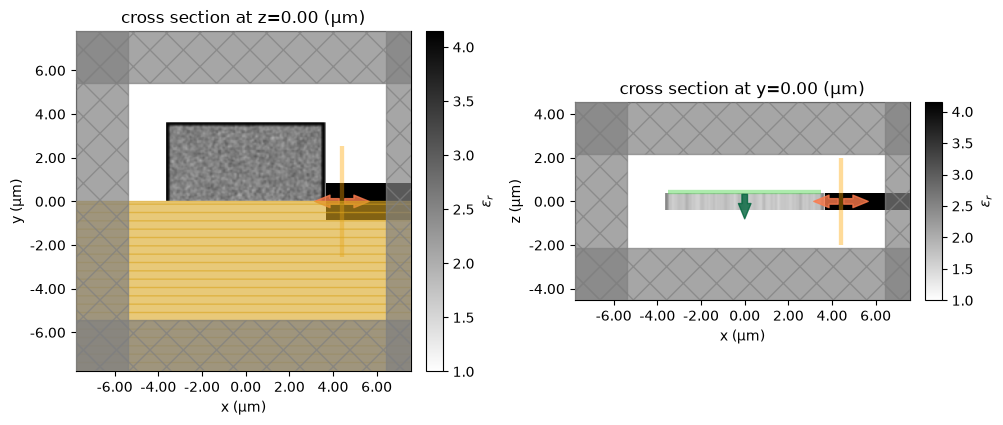

In [10]:
init_design = make_adjoint_sim(init_par)

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 10))
init_design.plot_eps(z=0, ax=ax1)
init_design.plot_eps(y=0, ax=ax2)
plt.show()

In [11]:
from tidy3d.plugins.autograd import make_erosion_dilation_penalty

erode_dilate_penalty = make_erosion_dilation_penalty(filter_radius, dr_grid_size)

# Figure of Merit (FoM) calculation.
def FoM(sim_data: td.SimulationData) -> float:
    """Return the power at the mode index of interest."""
    output_amps = sim_data[FoM_name].amps
    amp = output_amps.sel(direction="+", f=freq, mode_index=0).values
    return anp.sum(anp.abs(amp) ** 2)

def penalty(params, beta) -> float:
    """Penalty function based on amount of change in parameters after erosion and dilation."""
    rho = pre_process(params, beta=beta)
    return erode_dilate_penalty(rho)

def blur(x):
    """Fast differentiable 2D blur using array slicing, avoiding autograd incompatible in-place assignments."""
    sl = anp.pad(x[1:, :], ((0, 1), (0, 0)), mode='constant')
    sr = anp.pad(x[:-1, :], ((1, 0), (0, 0)), mode='constant')
    su = anp.pad(x[:, 1:], ((0, 0), (0, 1)), mode='constant')
    sd = anp.pad(x[:, :-1], ((0, 0), (1, 0)), mode='constant')
    return (2.0 * x + sl + sr + su + sd) / 6.0

def custom_connectivity_penalty(params, beta) -> float:
    """
    Strict topological connectivity constraint via a Diffusion (Flood-Fill) process.
    We initialize a signal at the boundary frame and flow it inwards only 
    through high-density material. Disconnected blocks are penalized.
    """
    rho = pre_process(params, beta=beta)
    
    # Downsample to greatly speed up the 2D diffusion traversal without affecting topology tracking
    factor = 5
    pad_x = (factor - rho.shape[0] % factor) % factor
    pad_y = (factor - rho.shape[1] % factor) % factor
    rho_padded = anp.pad(rho, ((0, pad_x), (0, pad_y)), mode='constant')
    
    new_nx = rho_padded.shape[0] // factor
    new_ny = rho_padded.shape[1] // factor
    rho_coarse = rho_padded.reshape(new_nx, factor, new_ny, factor).mean(axis=(1, 3))
    
    # The border frame acts as the structural connector anchor seed.
    b_mask_np = np.zeros((new_nx, new_ny))
    b_mask_np[0, :] = 1.0   # left edge
    b_mask_np[-1, :] = 1.0  # right edge
    b_mask_np[:, -1] = 1.0  # top edge
    b_mask = anp.array(b_mask_np)
    
    # Seed connectivity signal
    C = b_mask * rho_coarse
    for _ in range(40):  # Iteratively spread the signal, allowing long bridges to pass verification
        C_blur = blur(C)
        C_new = rho_coarse * anp.tanh(3.0 * C_blur)
        C = C_new * (1.0 - b_mask) + rho_coarse * b_mask
        
    # Any block of material that did not receive the connectivity signal receives a penalty
    island_mask = rho_coarse * (1.0 - C)
    return anp.sum(island_mask) / (new_nx * new_ny)

# Objective function to be passed to the optimization algorithm.
def obj(design_param, beta: float = 1.0, step_num: int = None, verbose: bool = False) -> float:
    sim = make_adjoint_sim(design_param, beta)
    task_name = "inv_des"
    if step_num:
        task_name += f"_step_{step_num}"
    sim_data = web.run(sim, task_name=task_name, verbose=verbose)
    
    FoM_val = FoM(sim_data)
    feature_size_penalty = penalty(design_param, beta=beta)
    # conn_penalty = custom_connectivity_penalty(design_param, beta=beta)
    
    print(f"\tFoM: {FoM_val}\n\tFeature Size Penalty: {feature_size_penalty}")
    J = FoM_val - feature_size_penalty #- 0.5*conn_penalty
    return J


# Function to calculate the objective function value and its
# gradient with respect to the design parameters.
obj_grad = value_and_grad(obj)

## Optimization

We need to provide an objective function and its gradients with respect
to the design parameters of the optimization algorithm.

Next we will define the optimizer using Tidy3D’s built-in Adam helper.

### Checking For a Previous Optimization

If `history_fname` is a valid file, the results of a previous
optimization are loaded, then the optimization will continue from the
last iteration step.

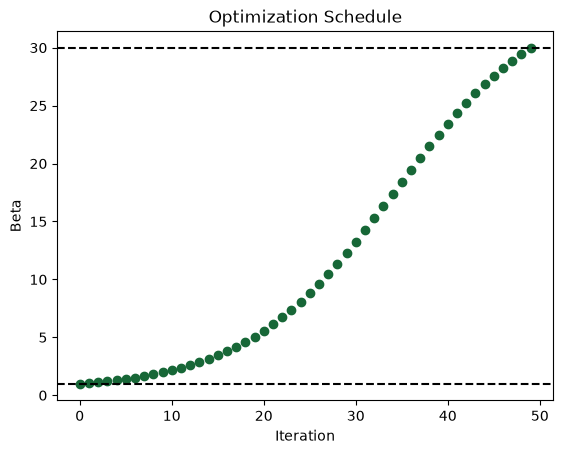

In [12]:
def normalized_tanh(x, beta, eta=0.5):
    num = np.tanh(beta * eta) + np.tanh(beta * (x - eta))
    denom = np.tanh(beta * eta) + np.tanh(beta * (1 - eta))
    return num / denom

total_iter = 50
beta_min = 1
beta_max = 30
beta_list = normalized_tanh(np.linspace(0, 1, total_iter), 3, eta=0.7)*(beta_max - beta_min) + beta_min
plt.scatter(range(total_iter), beta_list)
plt.axhline(y=beta_min, color='k', linestyle='--')
plt.axhline(y=beta_max, color='k', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Beta')
plt.title('Optimization Schedule')
plt.show()


In [29]:
import pickle

from tidy3d.plugins.autograd.optimizers import adam, apply_updates

# hyperparameters
learning_rate = 0.2
optimizer = adam(learning_rate=learning_rate)

# where to store history
history_fname = "misc/inverse_design_3_history.pkl"


def save_history(history_dict: dict) -> None:
    """Convenience function to save the history to file."""
    with open(history_fname, "wb") as file:
        pickle.dump(history_dict, file)


def load_history() -> dict:
    """Convenience method to load the history from file."""
    with open(history_fname, "rb") as file:
        history_dict = pickle.load(file)
    return history_dict

try:
    history_dict = load_history()
    opt_state = history_dict["opt_states"][-1]
    params = history_dict["params"][-1]
    num_iters_completed = len(history_dict["params"])
    print("Loaded optimization checkpoint from file.")
    print(f"Found {num_iters_completed} iterations previously completed out of {total_iter} total.")
    if num_iters_completed < total_iter:
        print("Will resume optimization.")
    else:
        print("Optimization completed, will return results.")

except FileNotFoundError:
    params = np.array(init_par)
    opt_state = optimizer.init(params)
    history_dict = dict(
        values=[],
        params=[],
        gradients=[],
        opt_states=[opt_state],
        data=[],
        beta=[],
    )

iter_done = len(history_dict["values"])



for i in range(iter_done, total_iter):
    break
    print(f"iteration = ({i + 1} / {total_iter})")

    beta_i = beta_list[i]
    value, gradient = obj_grad(params, beta=beta_i)

    # outputs
    print(f"\tbeta = {beta_i}")
    print(f"\tJ = {value:.4e}")
    print(f"\tgrad_norm = {np.linalg.norm(gradient):.4e}")

    # compute and apply updates to the optimizer based on gradient (-1 sign to maximize obj_fn)
    updates, opt_state = optimizer.update(-gradient, opt_state, params)
    params[:] = apply_updates(params, updates)

    # cap parameters between 0 and 1
    np.clip(params, 0.0, 1.0, out=params)

    # save history
    history_dict["values"].append(value)
    history_dict["params"].append(params)
    history_dict["beta"].append(beta_i)
    history_dict["gradients"].append(gradient)
    history_dict["opt_states"].append(opt_state)
    # history_dict["data"].append(sim_data_i) # uncomment to store data, can create large files
    save_history(history_dict)

Loaded optimization checkpoint from file.
Found 5 iterations previously completed out of 50 total.
Will resume optimization.


### Optimization Results

We can visualize the field distributions and the wavelength dependent coupling efficiency.

In [30]:
obj_vals = np.array(history_dict["values"])
final_par = history_dict["params"][-1]
final_beta = history_dict["beta"][-1]

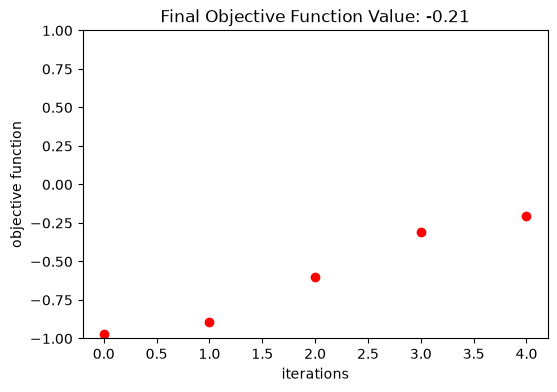

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(obj_vals, "ro")
ax.set_xlabel("iterations")
ax.set_ylabel("objective function")
ax.set_ylim(-1, 1)
ax.set_title(f"Final Objective Function Value: {obj_vals[-1]:.2f}")
plt.show()

The final grating coupler structure is well binarized, with mostly black
(`eps_max`) and white (`eps_min`) regions.

iteration 0: J = -9.7218e-01
iteration 0: beta = 1.0


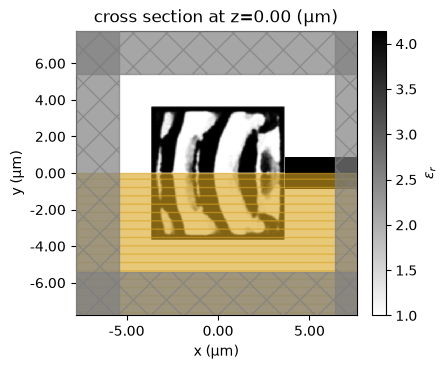

iteration 1: J = -8.9009e-01
iteration 1: beta = 1.0650718457938382


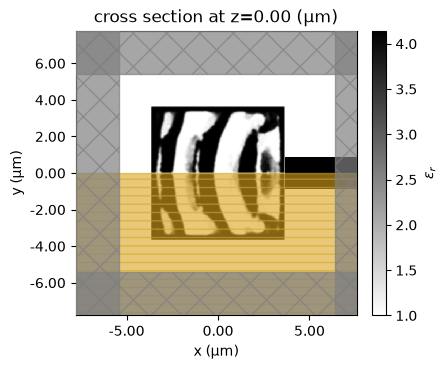

iteration 2: J = -5.9950e-01
iteration 2: beta = 1.1383197531952622


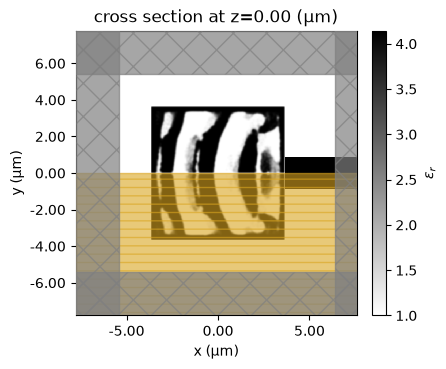

iteration 3: J = -3.0846e-01
iteration 3: beta = 1.2207279191356153


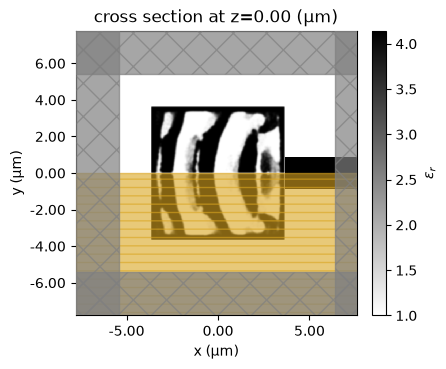

iteration 4: J = -2.0720e-01
iteration 4: beta = 1.3133873903468065


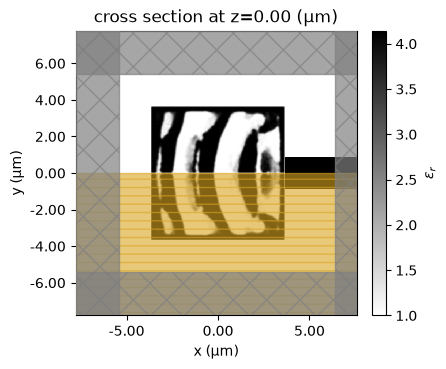

In [ ]:
obj_vals = np.array(history_dict["values"])
# final_par = history_dict["params"][-1]
# final_beta = history_dict["beta"][-1]

for i in range(len(obj_vals)):
    print(f"iteration {i}: J = {obj_vals[i]:.4e}")
    print(f"iteration {i}: beta = {history_dict['beta'][i]}")
    plt.figure(figsize=(4, 4), num=i)
    sim = make_adjoint_sim(history_dict["params"][i], beta=history_dict["beta"][i], unfold=True)
    sim.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=plt.gca())
    plt.show()